# Granger Causality Analysis - Infant EEG Dataset

This notebook implements a minimal Granger causality analysis pipeline following the simplified roadmap.

## Step 1: Load Data

Load EDF file with MNE and extract EEG channels and sampling rate.

In [40]:
# Import required libraries
import mne
import numpy as np
import os
from pathlib import Path

# Suppress MNE warnings for cleaner output
mne.set_log_level('WARNING')

In [41]:
# Set dataset path
dataset_path = Path('/home/alookaladdoo/DPCN-Project/Dataset')

# Get list of all subjects
subjects = sorted([d for d in os.listdir(dataset_path) if d.startswith('sub-NORB')])
print(f"Found {len(subjects)} subjects")

Found 103 subjects


In [42]:
# Function to find EDF files for a subject
def find_edf_files(subject_id):
    """Find all EDF files for a given subject."""
    subject_path = dataset_path / subject_id
    edf_files = []
    
    if subject_path.exists():
        # Search for EDF files in subject directory
        edf_files = list(subject_path.rglob('*.edf'))
    
    return edf_files

# Test with first subject
test_subject = subjects[63]
edf_files = find_edf_files(test_subject)
print(f"\n{test_subject}:")
print(f"  Found {len(edf_files)} EDF file(s)")
for edf in edf_files:
    print(f"  - {edf.name}")


sub-NORB00064:
  Found 3 EDF file(s)
  - sub-NORB00064_ses-3_task-EEG_eeg.edf
  - sub-NORB00064_ses-2_task-EEG_eeg.edf
  - sub-NORB00064_ses-1_task-EEG_eeg.edf


In [43]:
# Function to load EDF file
def load_edf_data(edf_path):
    """
    Load EDF file with MNE and extract EEG channels.
    
    Parameters:
    -----------
    edf_path : str or Path
        Path to the EDF file
        
    Returns:
    --------
    raw : mne.io.Raw
        Raw EEG data
    """
    # Load the EDF file
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    
    # Get info
    n_channels = len(raw.ch_names)
    sampling_rate = raw.info['sfreq']
    duration = raw.times[-1]
    
    print(f"\nLoaded: {Path(edf_path).name}")
    print(f"  Channels: {n_channels}")
    print(f"  Sampling rate: {sampling_rate} Hz")
    print(f"  Duration: {duration:.2f} seconds")
    print(f"  Channel names: {raw.ch_names}")
    
    return raw

# Load the first EDF file as a test
if edf_files:
    raw = load_edf_data(edf_files[0])
else:
    print("No EDF files found for testing")


Loaded: sub-NORB00064_ses-3_task-EEG_eeg.edf
  Channels: 19
  Sampling rate: 200.0 Hz
  Duration: 328.00 seconds
  Channel names: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']


In [44]:
# Extract EEG data as numpy array
if 'raw' in locals():
    # Get the data
    data = raw.get_data()  # Shape: (n_channels, n_timepoints)
    sampling_rate = raw.info['sfreq']
    channel_names = raw.ch_names
    
    print(f"\nExtracted data shape: {data.shape}")
    print(f"  Number of channels: {data.shape[0]}")
    print(f"  Number of timepoints: {data.shape[1]}")
    print(f"  Duration: {data.shape[1] / sampling_rate:.2f} seconds")


Extracted data shape: (19, 65600)
  Number of channels: 19
  Number of timepoints: 65600
  Duration: 328.00 seconds


## Step 2: Preprocess

Segment data based on annotations from `derivatives/NeuronicEEG` folder. These annotations mark specific time periods (typically 2.56 seconds) labeled as 'eyes_closed' that were identified through visual inspection for quantitative analysis.

In [45]:
# Detect and remove bad channels
def detect_bad_channels(raw, flat_threshold=1e-12, noise_threshold=1e-3):
    """
    Detect bad channels (flat or extremely noisy).
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    flat_threshold : float
        Threshold for flat channels (std < threshold)
    noise_threshold : float
        Threshold for noisy channels (std > threshold)
        
    Returns:
    --------
    bad_channels : list
        List of bad channel names
    """
    data = raw.get_data()
    channel_names = raw.ch_names
    bad_channels = []
    
    # Define reference/ground channel names to exclude
    ref_ground_channels = {'PG1', 'PG2', 'REF', 'GND', 'GROUND', '25+', '26+', '27+'}
    
    for i, ch_name in enumerate(channel_names):
        ch_data = data[i, :]
        ch_std = np.std(ch_data)
        ch_range = np.max(ch_data) - np.min(ch_data)
        
        is_bad = False
        
        # Check if flat
        if ch_std < flat_threshold:
            is_bad = True
        
        # Check if too noisy
        elif ch_std > noise_threshold:
            is_bad = True
        
        # Check if constant value
        elif ch_range == 0:
            is_bad = True
        
        # Check for reference/ground channels
        elif ch_name.upper() in ref_ground_channels:
            is_bad = True
        
        if is_bad:
            bad_channels.append(ch_name)
    
    print(f"\nFound {len(bad_channels)} bad channel(s): {bad_channels}")
    
    return bad_channels

# Detect bad channels
if 'raw' in locals():
    bad_channels = detect_bad_channels(raw)
    
    # Remove bad channels if any found
    if bad_channels:
        raw_clean = raw.copy()
        raw_clean.drop_channels(bad_channels)
        print(f"\nRemoved {len(bad_channels)} bad channel(s)")
        print(f"Remaining channels ({len(raw_clean.ch_names)}): {raw_clean.ch_names}")
    else:
        raw_clean = raw.copy()
        print("\nNo bad channels detected. Proceeding with all channels.")
    
    # Create raw_filtered alias (data is already filtered at acquisition)
    raw_filtered = raw_clean  # For compatibility with downstream code
else:
    print("Error: 'raw' data not found. Please run Step 1 first.")


Found 0 bad channel(s): []

No bad channels detected. Proceeding with all channels.


In [46]:
# Segment data based on annotation file
import pandas as pd

def load_annotations(subject_id, session_id, dataset_path):
    """
    Load annotation file for a given subject and session.
    Handles TSV files with trailing tabs/whitespace robustly.
    
    Parameters:
    -----------
    subject_id : str
        Subject ID (e.g., 'sub-NORB00001')
    session_id : str
        Session ID (e.g., 'ses-1')
    dataset_path : Path
        Path to dataset directory
        
    Returns:
    --------
    annotations_df : pd.DataFrame or None
        DataFrame with columns: onset, duration, label
    """
    annotations_path = dataset_path / 'derivatives' / 'NeuronicEEG' / subject_id / session_id / 'eeg' / f'{subject_id}_{session_id}_task-EEG_annotations.tsv'
    
    if annotations_path.exists():
        # Read file line by line to handle trailing tabs properly
        with open(annotations_path, 'r') as f:
            lines = f.readlines()
        
        # Parse manually to avoid pandas issues with trailing tabs
        data = []
        header = None
        
        for i, line in enumerate(lines):
            # Split by tab and strip whitespace from each field
            fields = [field.strip() for field in line.strip().split('\t')]
            
            if i == 0:
                # Header row
                header = fields[:3]  # Only take first 3 columns: onset, duration, label
            else:
                # Data row - only take first 3 fields
                if len(fields) >= 3 and fields[0] and fields[1]:  # Ensure we have onset and duration
                    try:
                        onset = float(fields[0])
                        duration = float(fields[1])
                        label = fields[2] if fields[2] else 'eyes_closed'  # Default if empty
                        data.append([onset, duration, label])
                    except ValueError:
                        continue  # Skip malformed lines
        
        if data:
            annotations_df = pd.DataFrame(data, columns=['onset', 'duration', 'label'])
            return annotations_df
        else:
            print(f"  Warning: No valid data in annotations file: {annotations_path}")
            return None
    else:
        print(f"  Warning: No annotations file found at {annotations_path}")
        return None

def segment_data_from_annotations(raw, annotations_df, label='eyes_closed'):
    """
    Segment EEG data based on annotations file.
    Only extracts segments marked with the specified label (e.g., 'eyes_closed').
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    annotations_df : pd.DataFrame
        DataFrame with columns: onset, duration, label
    label : str
        Label to filter segments by (default: 'eyes_closed')
        
    Returns:
    --------
    segments : list of numpy arrays
        List of data segments, each with shape (n_channels, n_samples_per_segment)
    segment_info : list of dict
        List of dictionaries containing segment metadata (onset, duration)
    """
    sfreq = raw.info['sfreq']
    data = raw.get_data()
    n_channels, n_samples = data.shape
    
    # Filter annotations by label (case-insensitive + Spanish support)
    # Accept both 'eyes_closed' and Spanish 'ojos_cerrados'
    label_lower = label.lower()
    filtered_annotations = annotations_df[
        (annotations_df['label'].str.lower() == label_lower) |
        (annotations_df['label'].str.lower() == 'ojos_cerrados') |
        (annotations_df['label'].str.lower() == 'vigilia_ojos_abiertos') |
        (annotations_df['label'].str.lower() == 'sue o_espontaneo')
    ]
    
    segments = []
    segment_info = []
    
    print(f"\nSegmenting data from annotations file...")
    print(f"  Total annotations: {len(annotations_df)}")
    print(f"  Unique labels found: {annotations_df['label'].unique().tolist()}")
    print(f"  Annotations matching '{label}' {len(filtered_annotations)}")
    
    for idx, row in filtered_annotations.iterrows():
        onset = row['onset']  # in seconds
        duration = row['duration']  # in seconds
        
        # Convert to sample indices
        start_sample = int(onset * sfreq)
        end_sample = int((onset + duration) * sfreq)
        
        # Check if segment is within bounds
        if start_sample >= 0 and end_sample <= n_samples:
            segment = data[:, start_sample:end_sample]
            segments.append(segment)
            segment_info.append({
                'onset': onset,
                'duration': duration,
                'start_sample': start_sample,
                'end_sample': end_sample
            })
        else:
            print(f"  Warning: Segment at onset={onset}s exceeds data bounds, skipping")
    
    print(f"\nExtracted {len(segments)} valid segments")
    
    return segments, segment_info

# Apply segmentation based on annotations
if 'raw_clean' in locals():
    # Extract subject and session info from the loaded EDF file
    if 'edf_files' in locals() and edf_files:
        edf_name = edf_files[0].stem
        parts = edf_name.split('_')
        subject_id = parts[0]  # e.g., 'sub-NORB00042'
        session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-1'
        
        # Load annotations
        annotations_df = load_annotations(subject_id, session_id, dataset_path)
        
        if annotations_df is not None:
            # Segment data based on annotations
            segments, segment_info = segment_data_from_annotations(raw_clean, annotations_df, label='eyes_closed')
            
            if len(segments) > 0:
                print(f"\n✓ Successfully segmented data for {subject_id} {session_id}")
            else:
                print(f"\n⚠ No valid segments found for {subject_id} {session_id}")
        else:
            print(f"\n⚠ Could not load annotations. Skipping segmentation.")
    else:
        print("Error: EDF file information not found.")
else:
    print("Error: 'raw_clean' data not found. Please run bad channel detection first.")


Segmenting data from annotations file...
  Total annotations: 18
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 18

Extracted 17 valid segments

✓ Successfully segmented data for sub-NORB00064 ses-3


In [47]:
# Normalize/Standardize segments for VAR model
def normalize_segments(segments):
    """
    Standardize each segment by z-scoring each channel.
    This ensures all channels have similar scales for VAR modeling.
    
    Parameters:
    -----------
    segments : list of numpy arrays
        List of data segments, each with shape (n_channels, n_samples)
        
    Returns:
    --------
    normalized_segments : list of numpy arrays
        Standardized segments
    """
    normalized_segments = []
    
    for segment in segments:
        # Z-score normalization: (x - mean) / std for each channel
        mean = segment.mean(axis=1, keepdims=True)
        std = segment.std(axis=1, keepdims=True)
        
        # Avoid division by zero for flat channels
        std[std == 0] = 1
        
        normalized_segment = (segment - mean) / std
        normalized_segments.append(normalized_segment)
    
    return normalized_segments

# Apply normalization
if 'segments' in locals() and len(segments) > 0:
    segments_normalized = normalize_segments(segments)
    
    print(f"\nNormalized {len(segments_normalized)} segments")
    print(f"  Original segment mean: {segments[0].mean():.2e}, std: {segments[0].std():.2e}")
    print(f"  Normalized segment mean: {segments_normalized[0].mean():.2e}, std: {segments_normalized[0].std():.2f}")
else:
    print("Error: No segments found.")


Normalized 17 segments
  Original segment mean: -4.84e-06, std: 2.35e-05
  Normalized segment mean: -2.56e-18, std: 1.00


## Step 3: Compute Granger Causality

Select model order using AIC, fit VAR model, and calculate GC values for all channel pairs.

In [48]:
# Import statsmodels for VAR model
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')  # Suppress convergence warnings

In [49]:
# Select optimal model order using BIC
def select_model_order(segment, max_order=20):
    model = VAR(segment.T)
    bic_values = {}
    for order in range(1, max_order + 1):
        try:
            bic_values[order] = model.fit(order, verbose=False).bic
        except:
            continue
    return min(bic_values, key=bic_values.get) if bic_values else 1

# Test on first segment
if 'segments' in locals() and len(segments) > 0:
    optimal_order = select_model_order(segments[0], max_order=20)
    print(f"Optimal model order (BIC): {optimal_order}")
else:
    print("Error: No segments found.")

Optimal model order (BIC): 3


In [50]:
# Fit VAR model on each window
def fit_var_models(segments, order):
    """Fit VAR model on each segment."""
    fitted_models = []
    n_segments = len(segments)
    
    for idx, segment in enumerate(segments, 1):
        model = VAR(segment.T)
        fitted_models.append(model.fit(order, verbose=False))
    
    print()  # New line after progress
    return fitted_models

# Fit VAR models using optimal order
if 'segments_normalized' in locals() and 'optimal_order' in locals():
    var_models = fit_var_models(segments_normalized, optimal_order)

    print(f"✓ Fitted {len(var_models)} VAR models with order {optimal_order}")
else:
    print("Error: Need normalized segments and optimal order.")


✓ Fitted 17 VAR models with order 3


In [51]:
# Calculate Granger causality for all channel pairs
def compute_gc_matrix(var_model, n_channels):
    """Compute GC matrix from fitted VAR model."""
    gc_matrix = np.zeros((n_channels, n_channels))
    for i in range(n_channels):
        for j in range(n_channels):
            if i != j:
                gc_result = var_model.test_causality(i, j, kind='f')
                gc_matrix[j, i] = -np.log(gc_result.pvalue + 1e-10)  # -log(p-value)
    return gc_matrix

# Compute GC for each window
if 'var_models' in locals():
    n_channels = len(raw_filtered.ch_names)
    n_windows = len(var_models)
    gc_matrices = []
    
    print(f"Computing GC matrices for {n_windows} windows...")
    for window_idx, model in enumerate(var_models, 1):
        gc_matrix = compute_gc_matrix(model, n_channels)
        gc_matrices.append(gc_matrix)
        
        # Progress meter
        progress = (window_idx / n_windows) * 100
        print(f"  Progress: {window_idx}/{n_windows} ({progress:.1f}%)", end='\r')
    
    print(f"\n✓ Computed GC matrices for {len(gc_matrices)} windows")
else:
    print("Error: No VAR models found.")

Computing GC matrices for 17 windows...
  Progress: 17/17 (100.0%)
✓ Computed GC matrices for 17 windows
  Progress: 17/17 (100.0%)
✓ Computed GC matrices for 17 windows


In [52]:
# Average GC across windows
if 'gc_matrices' in locals():
    gc_avg = np.mean(gc_matrices, axis=0)
    print(f"\nAveraged GC matrix shape: {gc_avg.shape}")
    print(f"  Mean GC value: {gc_avg.mean():.4f}")
    print(f"  Max GC value: {gc_avg.max():.4f}")
else:
    print("Error: No GC matrices found.")


Averaged GC matrix shape: (19, 19)
  Mean GC value: 2.7556
  Max GC value: 22.8071


## Step 4: Save Results

Save GC matrix as `.npy` file and create heatmap visualization.

In [53]:
# Save GC matrix
if 'gc_avg' in locals() and 'edf_files' in locals():
    # Create results directory
    results_dir = Path('/home/alookaladdoo/DPCN-Project/results')
    results_dir.mkdir(exist_ok=True)
    
    # Extract subject and session info from EDF filename
    edf_name = edf_files[0].stem  # e.g., 'sub-NORB00001_ses-01_task-rest_eeg'
    parts = edf_name.split('_')
    subject_id = parts[0]  # sub-NORB00001
    session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-01'
    
    # Save GC matrix
    output_file = results_dir / f"{subject_id}_{session_id}_gc_matrix.npy"
    np.save(output_file, gc_avg)
    print(f"✓ Saved GC matrix to: {output_file}")
else:
    print("Error: GC matrix or EDF files not found.")

✓ Saved GC matrix to: /home/alookaladdoo/DPCN-Project/results/sub-NORB00064_ses-3_gc_matrix.npy


✓ Saved heatmap to: /home/alookaladdoo/DPCN-Project/results/sub-NORB00064_ses-3_gc_heatmap.png
  Original range: [0.0000, 22.8071]
  Normalized range: [0.0, 1.0]


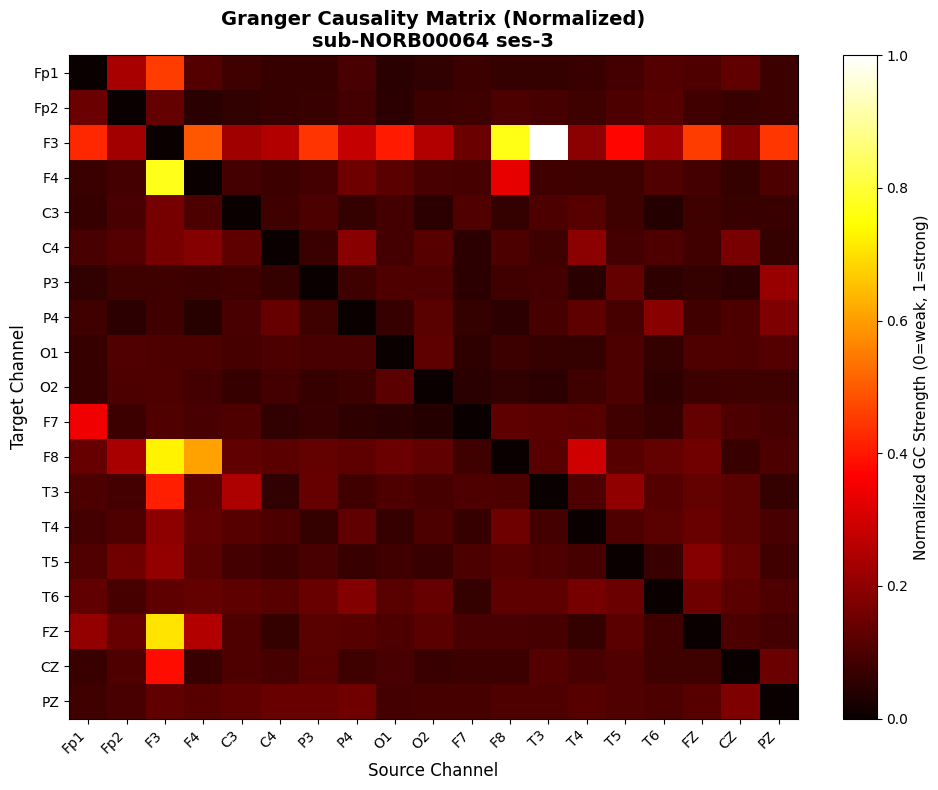

In [54]:
# Create and save heatmap
import matplotlib.pyplot as plt
if 'gc_avg' in locals() and 'raw_filtered' in locals():
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Normalize GC values to 0-1 range
    gc_min = gc_avg.min()
    gc_max = gc_avg.max()
    gc_normalized = (gc_avg - gc_min) / (gc_max - gc_min) if gc_max > gc_min else gc_avg
    
    # Create heatmap
    im = ax.imshow(gc_normalized, cmap='hot', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    
    # Set labels
    channel_names = raw_filtered.ch_names
    ax.set_xticks(range(len(channel_names)))
    ax.set_yticks(range(len(channel_names)))
    ax.set_xticklabels(channel_names, rotation=45, ha='right')
    ax.set_yticklabels(channel_names)
    
    # Labels and title
    ax.set_xlabel('Source Channel', fontsize=12)
    ax.set_ylabel('Target Channel', fontsize=12)
    ax.set_title(f'Granger Causality Matrix (Normalized)\n{subject_id} {session_id}', fontsize=14, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Normalized GC Strength (0=weak, 1=strong)', fontsize=11)
    
    plt.tight_layout()
    
    # Save figure
    output_fig = results_dir / f"{subject_id}_{session_id}_gc_heatmap.png"
    plt.savefig(output_fig, dpi=150, bbox_inches='tight')
    print(f"✓ Saved heatmap to: {output_fig}")
    print(f"  Original range: [{gc_min:.4f}, {gc_max:.4f}]")
    print(f"  Normalized range: [0.0, 1.0]")
    
    plt.show()
else:
    print("Error: GC matrix or channel names not found.")

## Step 5: Repeat for All Subjects

Loop through all 103 subjects and process each session independently.

In [55]:
# Process all subjects - Batch processing (using reusable functions)
def process_subject(subject_id, dataset_path, results_dir, max_order=20, fixed_order=None):
    """
    Process a single subject: load, preprocess, compute GC, and save results.
    Uses annotation-based segmentation from derivatives folder.
    
    Parameters:
    -----------
    subject_id : str
        Subject ID (e.g., 'sub-NORB00001')
    dataset_path : Path
        Path to dataset directory
    results_dir : Path
        Path to results directory
    max_order : int
        Maximum order for BIC search (ignored if fixed_order is set)
    fixed_order : int or None
        If set, use this order instead of searching
        
    Returns:
    --------
    dict : Processing results and status
    """
    try:
        # Find EDF files
        subject_path = dataset_path / subject_id
        edf_files = list(subject_path.rglob('*.edf'))
        
        if not edf_files:
            return {'subject': subject_id, 'status': 'no_files', 'sessions': 0}
        
        processed_sessions = []
        
        for edf_file in edf_files:
            try:
                # Extract session info from EDF filename
                edf_name = edf_file.stem
                parts = edf_name.split('_')
                session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-1'
                print(f"\nProcessing {subject_id} {session_id}...")
                
                # Load annotations using the reusable function
                annotations_df = load_annotations(subject_id, session_id, dataset_path)
                
                if annotations_df is None or len(annotations_df) == 0:
                    continue
                
                # Load EEG data
                raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
                
                # Detect and remove bad channels using the reusable function
                bad_channels = detect_bad_channels(raw)
                
                if bad_channels:
                    raw.drop_channels(bad_channels)
                
                if len(raw.ch_names) < 2:
                    continue
                
                # Segment data using the reusable function
                segments, segment_info = segment_data_from_annotations(raw, annotations_df, label='eyes_closed')
                
                if len(segments) < 1:
                    continue
                
                # Normalize segments using the reusable function
                segments_normalized = normalize_segments(segments)
                
                # Select model order
                if fixed_order is None:
                    order = select_model_order(segments_normalized[0], max_order=min(max_order, 10))
                else:
                    order = fixed_order
                
                # Fit VAR models using the reusable function
                var_models = fit_var_models(segments_normalized, order)
                
                # Compute GC matrices
                n_channels = len(raw.ch_names)
                gc_matrices = [compute_gc_matrix(model, n_channels) for model in var_models]
                
                # Average across windows
                gc_avg = np.mean(gc_matrices, axis=0)
                
                # Save results
                output_file = results_dir / f"{subject_id}_{session_id}_gc_matrix.npy"
                np.save(output_file, gc_avg)
                
                processed_sessions.append({
                    'session': session_id,
                    'channels': n_channels,
                    'segments': len(segments),
                    'order': order,
                    'output': output_file.name
                })
                
            except Exception as e:
                continue
        
        return {
            'subject': subject_id,
            'status': 'success',
            'sessions': len(processed_sessions),
            'details': processed_sessions
        }
        
    except Exception as e:
        return {'subject': subject_id, 'status': 'no_files', 'error': str(e)}


In [56]:
# Parallel batch processing
from joblib import Parallel, delayed
import multiprocessing

if 'subjects' in locals():
    print(f"Starting batch processing for {len(subjects)} subjects...")
    n_cores = multiprocessing.cpu_count()
    
    results_dir = Path('/home/alookaladdoo/DPCN-Project/results')
    results_dir.mkdir(exist_ok=True)
    
    # Process subjects in parallel
    all_results = Parallel(n_jobs=n_cores)(
        delayed(process_subject)(subject, dataset_path, results_dir, fixed_order=None)
        for subject in subjects
    )
    
    # Count results
    successful = sum(1 for r in all_results if r['status'] == 'success' and r['sessions'] > 0)
    no_files = sum(1 for r in all_results if r['status'] == 'no_files')
    failed = len(all_results) - successful - no_files
    
    print(f"Parallel batch processing complete!")
    print(f"  Successful: {successful}/{len(subjects)}")
    print(f"  No files: {no_files}/{len(subjects)}")
    print(f"  Failed: {failed}/{len(subjects)}")
    print(f"  Output directory: {results_dir}")
    
    # Show detailed results for failed subjects
    if failed > 0:
        print(f"\nFailed subjects:")
        for r in all_results:
            if r['status'] == 'error':
                print(f"  - {r['subject']}")
else:
    print("Error: Subjects list not found.")

Starting batch processing for 103 subjects...

Processing sub-NORB00005 ses-1...

Processing sub-NORB00003 ses-1...

Processing sub-NORB00006 ses-1...

Processing sub-NORB00007 ses-1...

Processing sub-NORB00001 ses-1...

Processing sub-NORB00016 ses-1...

Processing sub-NORB00010 ses-1...

Processing sub-NORB00008 ses-1...

Processing sub-NORB00009 ses-1...
Processing sub-NORB00012 ses-1...


Processing sub-NORB00013 ses-1...

Processing sub-NORB00014 ses-1...

Processing sub-NORB00004 ses-1...

Processing sub-NORB00015 ses-1...

Processing sub-NORB00002 ses-1...

Processing sub-NORB00011 ses-1...

Processing sub-NORB00005 ses-1...

Processing sub-NORB00003 ses-1...

Processing sub-NORB00006 ses-1...

Processing sub-NORB00007 ses-1...

Processing sub-NORB00001 ses-1...

Processing sub-NORB00016 ses-1...

Processing sub-NORB00010 ses-1...

Processing sub-NORB00008 ses-1...

Processing sub-NORB00009 ses-1...
Processing sub-NORB00012 ses-1...


Processing sub-NORB00013 ses-1...

Processi

/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.



Found 5 bad channel(s): ['Pg1', 'Pg2', '25+', '26+', '27+']

Segmenting data from annotations file...
  Total annotations: 24
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 24

Extracted 24 valid segments

Segmenting data from annotations file...
  Total annotations: 24
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 24

Extracted 24 valid segments



Processing sub-NORB00042 ses-1...

Processing sub-NORB00042 ses-1...


/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.



Found 5 bad channel(s): ['Pg1', 'Pg2', '25+', '26+', '27+']

Segmenting data from annotations file...
  Total annotations: 23
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 23

Extracted 23 valid segments



Processing sub-NORB00043 ses-1...

Processing sub-NORB00043 ses-1...


...


Found 5 bad channel(s): ['Pg1', 'Pg2', '25+', '26+', '27+']

Segmenting data from annotations file...
  Total annotations: 24
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 24

Extracted 24 valid segments


Processing sub-NORB00062 ses-1...


Processing sub-NORB00062 ses-1...


/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 30.0, setting values to 0 and Nyquist.



Found 5 bad channel(s): ['Pg1', 'Pg2', '25+', '26+', '27+']

Segmenting data from annotations file...
  Total annotations: 27
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 27

Extracted 27 valid segments



Processing sub-NORB00063 ses-1...

Processing sub-NORB00063 ses-1...


/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
/tmp/ipykernel_22346/2022214653.py:49: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 30.0, setting values to 0 and Nyquist.



Found 5 bad channel(s): ['Pg1', 'Pg2', '25+', '26+', '27+']

Segmenting data from annotations file...
  Total annotations: 24
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 24

Extracted 24 valid segments



Processing sub-NORB00064 ses-3...

Found 0 bad channel(s): []

Segmenting data from annotations file...
  Total annotations: 18
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 18

Extracted 17 valid segments

Processing sub-NORB00064 ses-3...

Found 0 bad channel(s): []

Segmenting data from annotations file...
  Total annotations: 18
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 18

Extracted 17 valid segments



Processing sub-NORB00065 ses-2...

Found 0 bad channel(s): []

Segmenting data from annotations file...
  Total annotations: 20
  Unique labels found: ['eyes_closed']
  Annotations matching 'eyes_closed' 20

Extracted 20 valid segments

Processing sub-NORB00065 ses-2...

Found 0 bad ch

## Step 6: Group Analysis

Load all GC matrices, compute group average, and create group heatmap.

In [61]:
# Load all GC matrices from results directory
results_dir = Path('/home/alookaladdoo/DPCN-Project/results')

if results_dir.exists():
    # Find all .npy files
    gc_files = sorted(list(results_dir.glob('*_gc_matrix.npy')))
    
    print(f"Found {len(gc_files)} GC matrix files in results directory")
    
    if len(gc_files) > 0:
        # Load all matrices
        all_gc_matrices = []
        valid_files = []
        
        for idx, gc_file in enumerate(gc_files, 1):
            try:
                gc_matrix = np.load(gc_file)
                all_gc_matrices.append(gc_matrix)
                valid_files.append(gc_file.stem)
                
            except Exception as e:
                print(f"\n  Warning: Could not load {gc_file.name}: {e}")
                continue
        
        print(f"\n✓ Successfully loaded {len(all_gc_matrices)} matrices")
        
        # Check if all matrices have same shape
        shapes = [m.shape for m in all_gc_matrices]
        unique_shapes = set(shapes)
        
        if len(unique_shapes) > 1:
            print(f"\n⚠ Warning: Found matrices with different shapes: {unique_shapes}")
            print("  Grouping by shape for separate analysis...")
            
            # Group by shape
            shape_groups = {}
            for matrix, filename in zip(all_gc_matrices, valid_files):
                shape = matrix.shape
                if shape not in shape_groups:
                    shape_groups[shape] = {'matrices': [], 'files': []}
                shape_groups[shape]['matrices'].append(matrix)
                shape_groups[shape]['files'].append(filename)
            
            # Analyze largest group
            largest_shape = max(shape_groups.keys(), key=lambda s: len(shape_groups[s]['matrices']))
            print(f"\n  Using largest group: {largest_shape} ({len(shape_groups[largest_shape]['matrices'])} sessions)")
            
            all_gc_matrices = shape_groups[largest_shape]['matrices']
            valid_files = shape_groups[largest_shape]['files']
        
        print(f"\n✓ Analysis set: {len(all_gc_matrices)} matrices with shape {all_gc_matrices[0].shape}")
        
    else:
        print("\n⚠ No GC matrix files found. Please run Step 5 first.")
        all_gc_matrices = None
else:
    print(f"\n⚠ Results directory not found: {results_dir}")
    print("  Please run Step 5 first to process subjects.")
    all_gc_matrices = None

Found 129 GC matrix files in results directory

✓ Successfully loaded 129 matrices

⚠ Warning: Found matrices with different shapes: {(19, 19), (2, 2)}
  Grouping by shape for separate analysis...

  Using largest group: (19, 19) (128 sessions)

✓ Analysis set: 128 matrices with shape (19, 19)


In [62]:
# Compute group average GC matrix
if all_gc_matrices is not None and len(all_gc_matrices) > 0:
    # Stack all matrices and compute mean
    gc_group_avg = np.mean(all_gc_matrices, axis=0)
    gc_group_std = np.std(all_gc_matrices, axis=0)
    
    print(f"Group Average GC Matrix:")
    print(f"  Shape: {gc_group_avg.shape}")
    print(f"  Mean GC value: {gc_group_avg.mean():.4f}")
    print(f"  Std GC value: {gc_group_avg.std():.4f}")
    print(f"  Min GC value: {gc_group_avg.min():.4f}")
    print(f"  Max GC value: {gc_group_avg.max():.4f}")
    print(f"  Number of subjects: {len(all_gc_matrices)}")
    
    # Save group average matrix
    output_file = results_dir / 'group_average_gc.npy'
    np.save(output_file, gc_group_avg)
    print(f"\n✓ Saved group average to: {output_file}")
    
    # Save group std matrix
    output_std_file = results_dir / 'group_std_gc.npy'
    np.save(output_std_file, gc_group_std)
    print(f"✓ Saved group std to: {output_std_file}")
else:
    print("Error: No GC matrices loaded.")

Group Average GC Matrix:
  Shape: (19, 19)
  Mean GC value: 3.3039
  Std GC value: 1.4347
  Min GC value: 0.0000
  Max GC value: 10.1424
  Number of subjects: 128

✓ Saved group average to: /home/alookaladdoo/DPCN-Project/results/group_average_gc.npy
✓ Saved group std to: /home/alookaladdoo/DPCN-Project/results/group_std_gc.npy



Found 2 bad channel(s): ['Pg1', 'Pg2']
  Using 19 channels: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, FZ, CZ, PZ

✓ Saved group heatmap to: /home/alookaladdoo/DPCN-Project/results/group_average_gc_heatmap.png
  Original range: [0.0000, 10.1424]
  Normalized range: [0.0, 1.0]

✓ Saved group heatmap to: /home/alookaladdoo/DPCN-Project/results/group_average_gc_heatmap.png
  Original range: [0.0000, 10.1424]
  Normalized range: [0.0, 1.0]


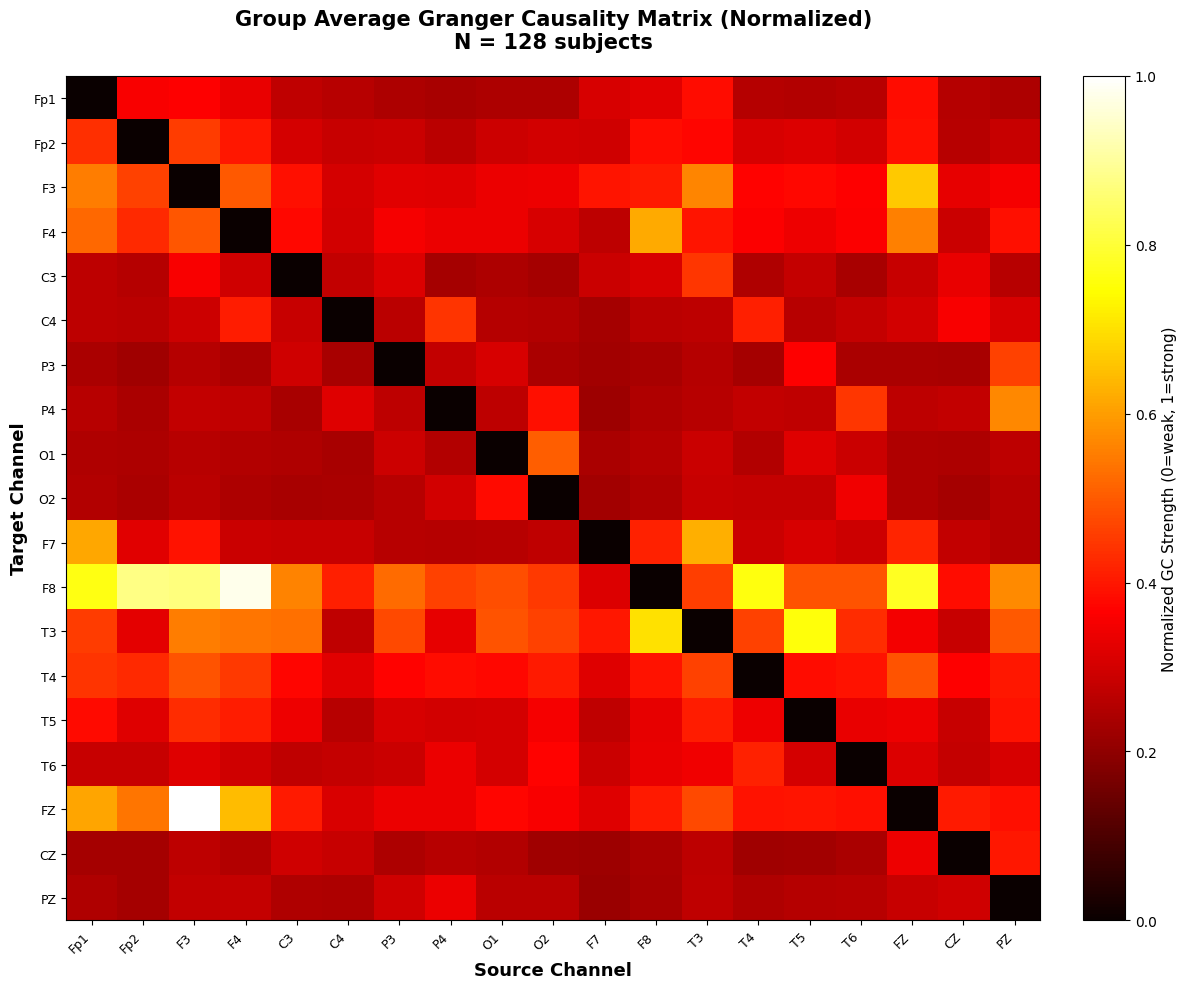


✓ Group analysis complete!
  Analyzed 128 subjects
  Files saved in: /home/alookaladdoo/DPCN-Project/results


In [85]:
# Create group heatmap
if 'gc_group_avg' in locals():
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Normalize GC values to 0-1 range
    gc_min = gc_group_avg.min()
    gc_max = gc_group_avg.max()
    gc_normalized = (gc_group_avg - gc_min) / (gc_max - gc_min) if gc_max > gc_min else gc_group_avg
    
    # Create heatmap
    im = ax.imshow(gc_normalized, cmap='hot', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    
    # Set labels (use channel names from first loaded matrix if available)
    n_channels = gc_group_avg.shape[0]
    
    # Try to get channel names from a sample file
    try:
        # Load a sample EDF to get channel names
        sample_subject = subjects[0] if 'subjects' in locals() else None
        if sample_subject:
            sample_files = list((dataset_path / sample_subject).rglob('*.edf'))
            if sample_files:
                sample_raw = mne.io.read_raw_edf(sample_files[0], preload=False, verbose=False)
                # Get bad channels and filter them out
                bad_ch = detect_bad_channels(sample_raw, 1e-12, 0.001)
                channel_names = [ch for ch in sample_raw.ch_names if ch not in bad_ch][:n_channels]
            else:
                channel_names = [f'Ch{i+1}' for i in range(n_channels)]
        else:
            channel_names = [f'Ch{i+1}' for i in range(n_channels)]
    except:
        channel_names = [f'Ch{i+1}' for i in range(n_channels)]
    
    # Ensure we have the right number of channel names
    if len(channel_names) != n_channels:
        channel_names = [f'Ch{i+1}' for i in range(n_channels)]
    
    print(f"  Using {len(channel_names)} channels: {', '.join(channel_names)}")
    
    ax.set_xticks(range(n_channels))
    ax.set_yticks(range(n_channels))
    ax.set_xticklabels(channel_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(channel_names, fontsize=9)
    
    # Labels and title
    ax.set_xlabel('Source Channel', fontsize=13, fontweight='bold')
    ax.set_ylabel('Target Channel', fontsize=13, fontweight='bold')
    ax.set_title(f'Group Average Granger Causality Matrix (Normalized)\nN = {len(all_gc_matrices)} subjects', 
                 fontsize=15, fontweight='bold', pad=20)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Normalized GC Strength (0=weak, 1=strong)', fontsize=11)
    
    plt.tight_layout()
    
    # Save figure
    output_fig = results_dir / 'group_average_gc_heatmap.png'
    plt.savefig(output_fig, dpi=200, bbox_inches='tight')
    print(f"\n✓ Saved group heatmap to: {output_fig}")
    print(f"  Original range: [{gc_min:.4f}, {gc_max:.4f}]")
    print(f"  Normalized range: [0.0, 1.0]")
    
    plt.show()
    
    print(f"\n✓ Group analysis complete!")
    print(f"  Analyzed {len(all_gc_matrices)} subjects")
    print(f"  Files saved in: {results_dir}")
else:
    print("Error: Group average GC matrix not computed.")

In [66]:
# Summary statistics for group analysis
if 'gc_group_avg' in locals() and 'gc_group_std' in locals():
    print("=" * 70)
    print("GROUP ANALYSIS SUMMARY")
    print("=" * 70)
    
    print(f"\n Dataset Statistics:")
    print(f"  Total subjects analyzed: {len(all_gc_matrices)}")
    print(f"  Matrix dimensions: {gc_group_avg.shape}")
    print(f"  Number of connections: {gc_group_avg.shape[0] * (gc_group_avg.shape[1] - 1)}")
    
    print(f"\n Group Average GC Values:")
    print(f"  Mean: {gc_group_avg.mean():.4f}")
    print(f"  Median: {np.median(gc_group_avg):.4f}")
    print(f"  Std: {gc_group_avg.std():.4f}")
    print(f"  Min: {gc_group_avg.min():.4f}")
    print(f"  Max: {gc_group_avg.max():.4f}")
    
    
    # Find strongest connections (excluding diagonal)
    n_ch = gc_group_avg.shape[0]
    mask = ~np.eye(n_ch, dtype=bool)
    flat_gc = gc_group_avg[mask]
    flat_indices = np.argsort(flat_gc)[-5:][::-1]  # Top 5
    
    print(f"\n Top 5 Strongest Group Connections:")
    row_indices, col_indices = np.where(mask)
    for rank, idx in enumerate(flat_indices, 1):
        i, j = row_indices[idx], col_indices[idx]
        gc_value = gc_group_avg[i, j]
        if len(channel_names) > max(i, j):
            print(f"  {rank}. {channel_names[j]} → {channel_names[i]}: {gc_value:.4f}")
        else:
            print(f"  {rank}. Ch{j+1} → Ch{i+1}: {gc_value:.4f}")
    
else:
    print("Error: Group analysis not completed.")

GROUP ANALYSIS SUMMARY

 Dataset Statistics:
  Total subjects analyzed: 128
  Matrix dimensions: (19, 19)
  Number of connections: 342

 Group Average GC Values:
  Mean: 3.3039
  Median: 3.0108
  Std: 1.4347
  Min: 0.0000
  Max: 10.1424

 Top 5 Strongest Group Connections:
  1. Ch3 → Ch17: 10.1424
  2. Ch4 → Ch12: 9.9359
  3. Ch2 → Ch12: 8.8902
  4. Ch3 → Ch12: 8.7962
  5. Ch17 → Ch12: 7.9193


✓ Saved network graph to: top_10_connections_network.png


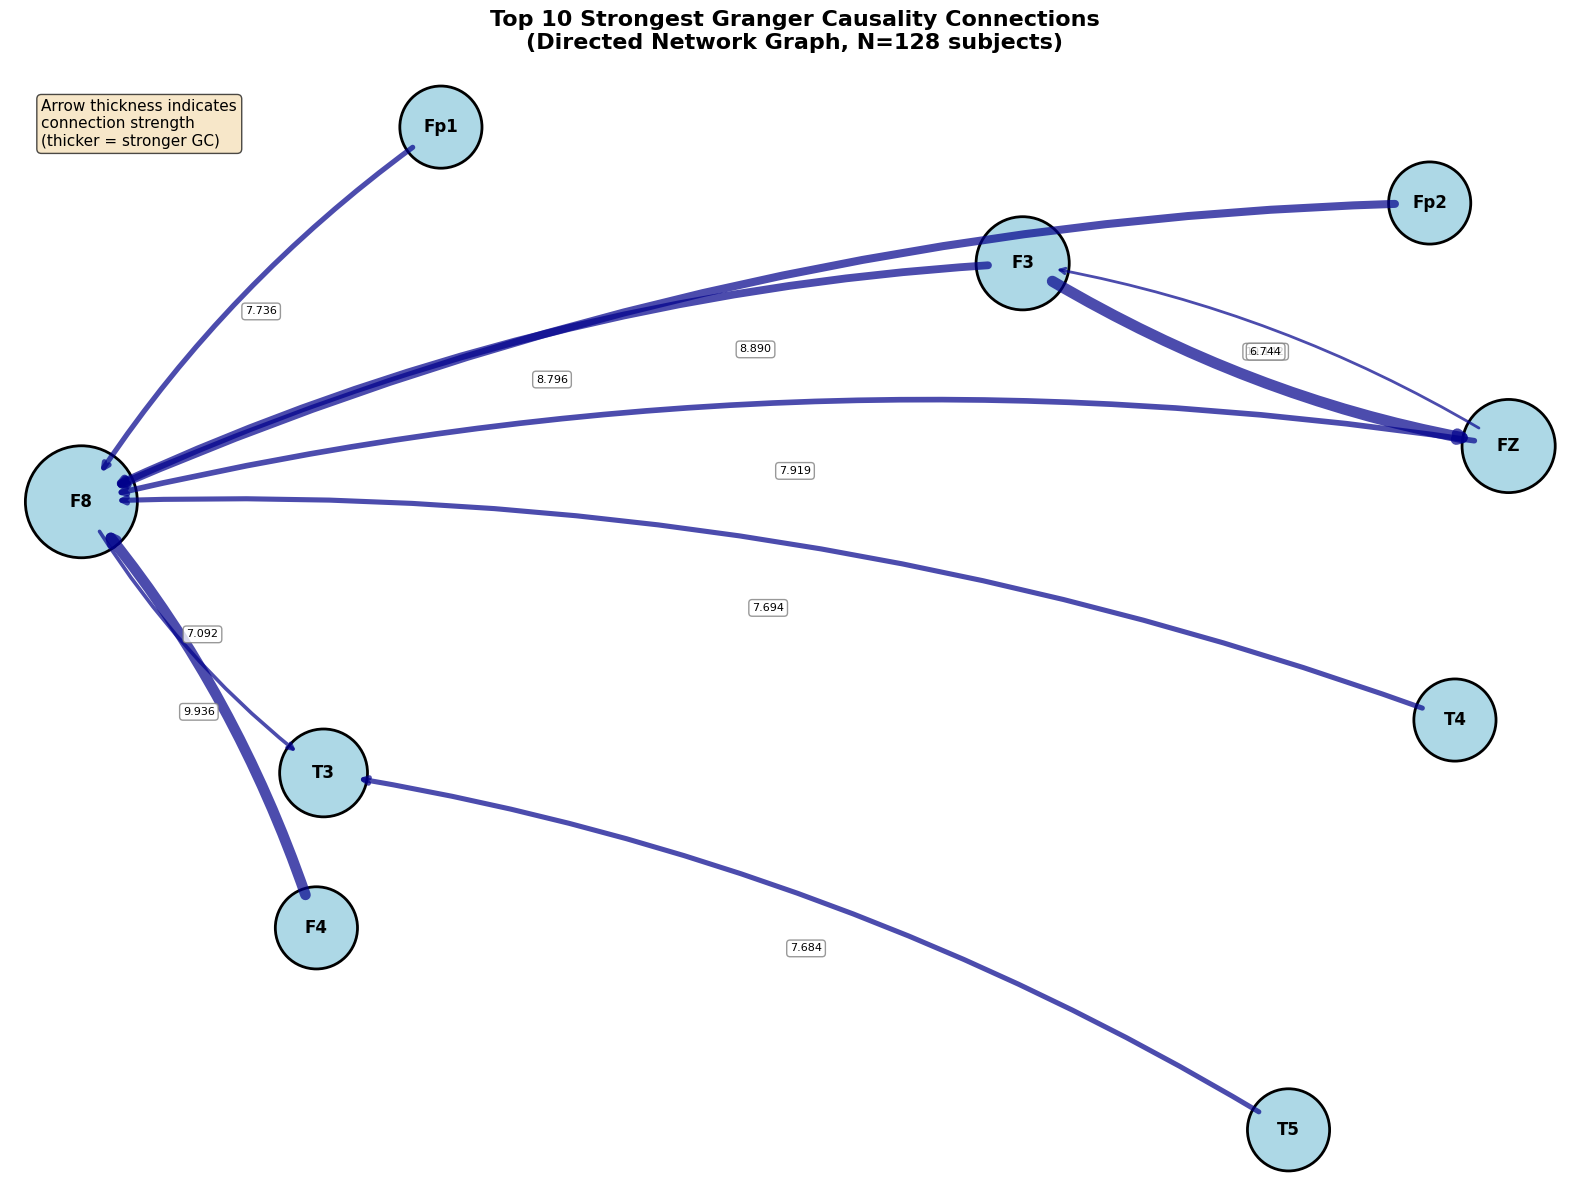


TOP 10 STRONGEST CONNECTIONS (DIRECTED NETWORK)
   1. F3    → FZ    : 10.1424
   2. F4    → F8    : 9.9359
   3. Fp2   → F8    : 8.8902
   4. F3    → F8    : 8.7962
   5. FZ    → F8    : 7.9193
   6. Fp1   → F8    : 7.7357
   7. T4    → F8    : 7.6940
   8. T5    → T3    : 7.6841
   9. F8    → T3    : 7.0920
  10. FZ    → F3    : 6.7438


In [109]:
# Visualize top 10 connections as a directed network graph
if 'gc_group_avg' in locals() and 'channel_names' in locals():
    import networkx as nx
    from matplotlib.patches import FancyArrowPatch, Circle
    
    # Extract top 10 connections (excluding diagonal)
    n_ch = gc_group_avg.shape[0]
    mask = ~np.eye(n_ch, dtype=bool)
    
    # Get all off-diagonal values with their indices
    row_indices, col_indices = np.where(mask)
    gc_values = gc_group_avg[mask]
    
    # Sort and get top 10
    top_10_indices = np.argsort(gc_values)[-10:][::-1]
    
    # Create directed graph
    G = nx.DiGraph()
    
    # Prepare data for plotting and graph
    connection_data = []
    max_gc = 0
    min_gc = float('inf')
    
    for idx in top_10_indices:
        i, j = row_indices[idx], col_indices[idx]
        gc_val = gc_group_avg[i, j]
        
        # Get channel names
        if len(channel_names) > max(i, j):
            source = channel_names[j]
            target = channel_names[i]
        else:
            source = f"Ch{j+1}"
            target = f"Ch{i+1}"
        
        # Add edge to graph
        G.add_edge(source, target, weight=gc_val)
        connection_data.append((source, target, gc_val))
        
        max_gc = max(max_gc, gc_val)
        min_gc = min(min_gc, gc_val)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Use spring layout for better visualization
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Draw nodes
    node_sizes = [3000 + G.degree(node) * 500 for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                          node_color='lightblue', 
                          edgecolors='black', 
                          linewidths=2, ax=ax)
    
    # Draw node labels
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)
    
    # Draw edges with varying thickness and color based on GC strength
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    
    # Normalize weights for edge width and color
    norm_weights = [(w - min_gc) / (max_gc - min_gc) for w in weights]
    
    # Draw edges
    for (source, target), weight, norm_weight in zip(edges, weights, norm_weights):
        # Edge width based on strength (thicker = stronger connection)
        edge_width = 2 + norm_weight * 6
        
        # Draw edge with arrow (uniform color)
        ax.annotate('',
                   xy=pos[target], xycoords='data',
                   xytext=pos[source], textcoords='data',
                   arrowprops=dict(arrowstyle='->', 
                                 connectionstyle='arc3,rad=0.1',
                                 color='darkblue',
                                 lw=edge_width,
                                 alpha=0.7,
                                 shrinkA=25, shrinkB=25))
        
        # Add edge label (GC value)
        edge_x = (pos[source][0] + pos[target][0]) / 2
        edge_y = (pos[source][1] + pos[target][1]) / 2
        ax.text(edge_x, edge_y, f'{weight:.3f}', 
               fontsize=8, ha='center', 
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                        edgecolor='gray', alpha=0.8))
    
    # Title and formatting
    ax.set_title(f'Top 10 Strongest Granger Causality Connections\n(Directed Network Graph, N={len(all_gc_matrices)} subjects)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')
    
    # Add legend for arrow thickness
    legend_text = "Arrow thickness indicates\nconnection strength\n(thicker = stronger GC)"
    ax.text(0.02, 0.98, legend_text, transform=ax.transAxes,
           fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    plt.tight_layout()
    
    # Save figure
    output_fig = results_dir / 'top_10_connections_network.png'
    plt.savefig(output_fig, dpi=200, bbox_inches='tight')
    print(f"✓ Saved network graph to: {output_fig.name}")
    
    plt.show()
    
    # Print summary
    print("\n" + "=" * 70)
    print("TOP 10 STRONGEST CONNECTIONS (DIRECTED NETWORK)")
    print("=" * 70)
    for rank, (source, target, gc_val) in enumerate(connection_data, 1):
        print(f"  {rank:2d}. {source:5s} → {target:5s} : {gc_val:.4f}")
    
else:
    print("Error: Group average GC matrix or channel names not found.")

## Step 7: Session-wise Comparison

Compare how Granger Causality changes across different sessions (ses-1, ses-2, ses-3, ses-4) for all subjects.

In [77]:
# Organize GC matrices by session
import re

# Load all GC matrices and organize by subject and session
results_dir = Path('/home/alookaladdoo/DPCN-Project/results')

if results_dir.exists():
    gc_files = sorted(list(results_dir.glob('*_gc_matrix.npy')))
    
    print(f"Found {len(gc_files)} GC matrix files")
    
    # Dictionary to store matrices: {subject_id: {session_id: matrix}}
    subject_session_data = {}
    
    for gc_file in gc_files:
        # Parse filename: sub-NORB00001_ses-1_gc_matrix.npy
        filename = gc_file.stem  # Remove .npy extension
        
        # Extract subject and session using regex
        match = re.match(r'(sub-NORB\d+)_(ses-\d+)_gc_matrix', filename)
        
        if match:
            subject_id = match.group(1)
            session_id = match.group(2)
            
            try:
                gc_matrix = np.load(gc_file)
                
                # Initialize subject dict if not exists
                if subject_id not in subject_session_data:
                    subject_session_data[subject_id] = {}
                
                # Store matrix
                subject_session_data[subject_id][session_id] = gc_matrix
                
            except Exception as e:
                print(f"  Warning: Could not load {gc_file.name}: {e}")
                continue
    
    print(f"\n✓ Loaded data for {len(subject_session_data)} subjects")
    
    # Count sessions
    session_counts = {}
    for subject_id, sessions in subject_session_data.items():
        for session_id in sessions.keys():
            session_counts[session_id] = session_counts.get(session_id, 0) + 1
    
    print(f"\n Session distribution:")
    for session_id in sorted(session_counts.keys()):
        print(f"  {session_id}: {session_counts[session_id]} subjects")
    
    # Find subjects with multiple sessions
    multi_session_subjects = {subj: sess for subj, sess in subject_session_data.items() if len(sess) > 1}
    print(f"\n Subjects with multiple sessions: {len(multi_session_subjects)}")
    
else:
    print(f"Error: Results directory not found: {results_dir}")
    subject_session_data = None

Found 129 GC matrix files

✓ Loaded data for 103 subjects

 Session distribution:
  ses-1: 103 subjects
  ses-2: 21 subjects
  ses-3: 4 subjects
  ses-4: 1 subjects

 Subjects with multiple sessions: 21


In [78]:
# Compute session-wise average GC matrices
if subject_session_data is not None:
    # Group matrices by session
    session_matrices = {}
    
    for subject_id, sessions in subject_session_data.items():
        for session_id, gc_matrix in sessions.items():
            if session_id not in session_matrices:
                session_matrices[session_id] = []
            session_matrices[session_id].append(gc_matrix)
    
    # Compute average for each session
    session_averages = {}
    session_stds = {}
    
    print("=" * 70)
    print("SESSION-WISE AVERAGE GC MATRICES")
    print("=" * 70)
    
    for session_id in sorted(session_matrices.keys()):
        matrices = session_matrices[session_id]
        
        # Check if all matrices have same shape
        shapes = [m.shape for m in matrices]
        unique_shapes = set(shapes)
        
        if len(unique_shapes) > 1:
            print(f"\n⚠ {session_id}: Multiple shapes found {unique_shapes}, using most common shape")
            # Use most common shape
            from collections import Counter
            most_common_shape = Counter(shapes).most_common(1)[0][0]
            matrices = [m for m in matrices if m.shape == most_common_shape]
        
        # Compute average
        session_avg = np.mean(matrices, axis=0)
        session_std = np.std(matrices, axis=0)
        
        session_averages[session_id] = session_avg
        session_stds[session_id] = session_std
        
        print(f"\n {session_id}:")
        print(f"  Subjects: {len(matrices)}")
        print(f"  Matrix shape: {session_avg.shape}")
        print(f"  Mean GC: {session_avg.mean():.4f} ± {session_std.mean():.4f}")
        print(f"  Min GC: {session_avg.min():.4f}")
        print(f"  Max GC: {session_avg.max():.4f}")
    
    # Save session averages
    for session_id, avg_matrix in session_averages.items():
        output_file = results_dir / f'{session_id}_average_gc.npy'
        np.save(output_file, avg_matrix)
        print(f"\n✓ Saved {session_id} average to: {output_file.name}")
    
    print(f"\n✓ Session-wise averages computed and saved")
    
else:
    print("Error: No session data loaded")

SESSION-WISE AVERAGE GC MATRICES

⚠ ses-1: Multiple shapes found {(19, 19), (2, 2)}, using most common shape

 ses-1:
  Subjects: 102
  Matrix shape: (19, 19)
  Mean GC: 3.1631 ± 2.1112
  Min GC: 0.0000
  Max GC: 8.9897

 ses-2:
  Subjects: 21
  Matrix shape: (19, 19)
  Mean GC: 3.8412 ± 1.9621
  Min GC: 0.0000
  Max GC: 17.3101

 ses-3:
  Subjects: 4
  Matrix shape: (19, 19)
  Mean GC: 3.6947 ± 1.7935
  Min GC: 0.0000
  Max GC: 16.9610

 ses-4:
  Subjects: 1
  Matrix shape: (19, 19)
  Mean GC: 4.8185 ± 0.0000
  Min GC: 0.0000
  Max GC: 23.0258

✓ Saved ses-1 average to: ses-1_average_gc.npy

✓ Saved ses-2 average to: ses-2_average_gc.npy

✓ Saved ses-3 average to: ses-3_average_gc.npy

✓ Saved ses-4 average to: ses-4_average_gc.npy

✓ Session-wise averages computed and saved



Found 2 bad channel(s): ['Pg1', 'Pg2']
Creating heatmaps for 4 sessions...
  Global range: [0.0000, 23.0258]
  Using 19 channels: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, FZ, CZ, PZ

✓ Saved session comparison heatmaps to: session_comparison_heatmaps.png

✓ Saved session comparison heatmaps to: session_comparison_heatmaps.png


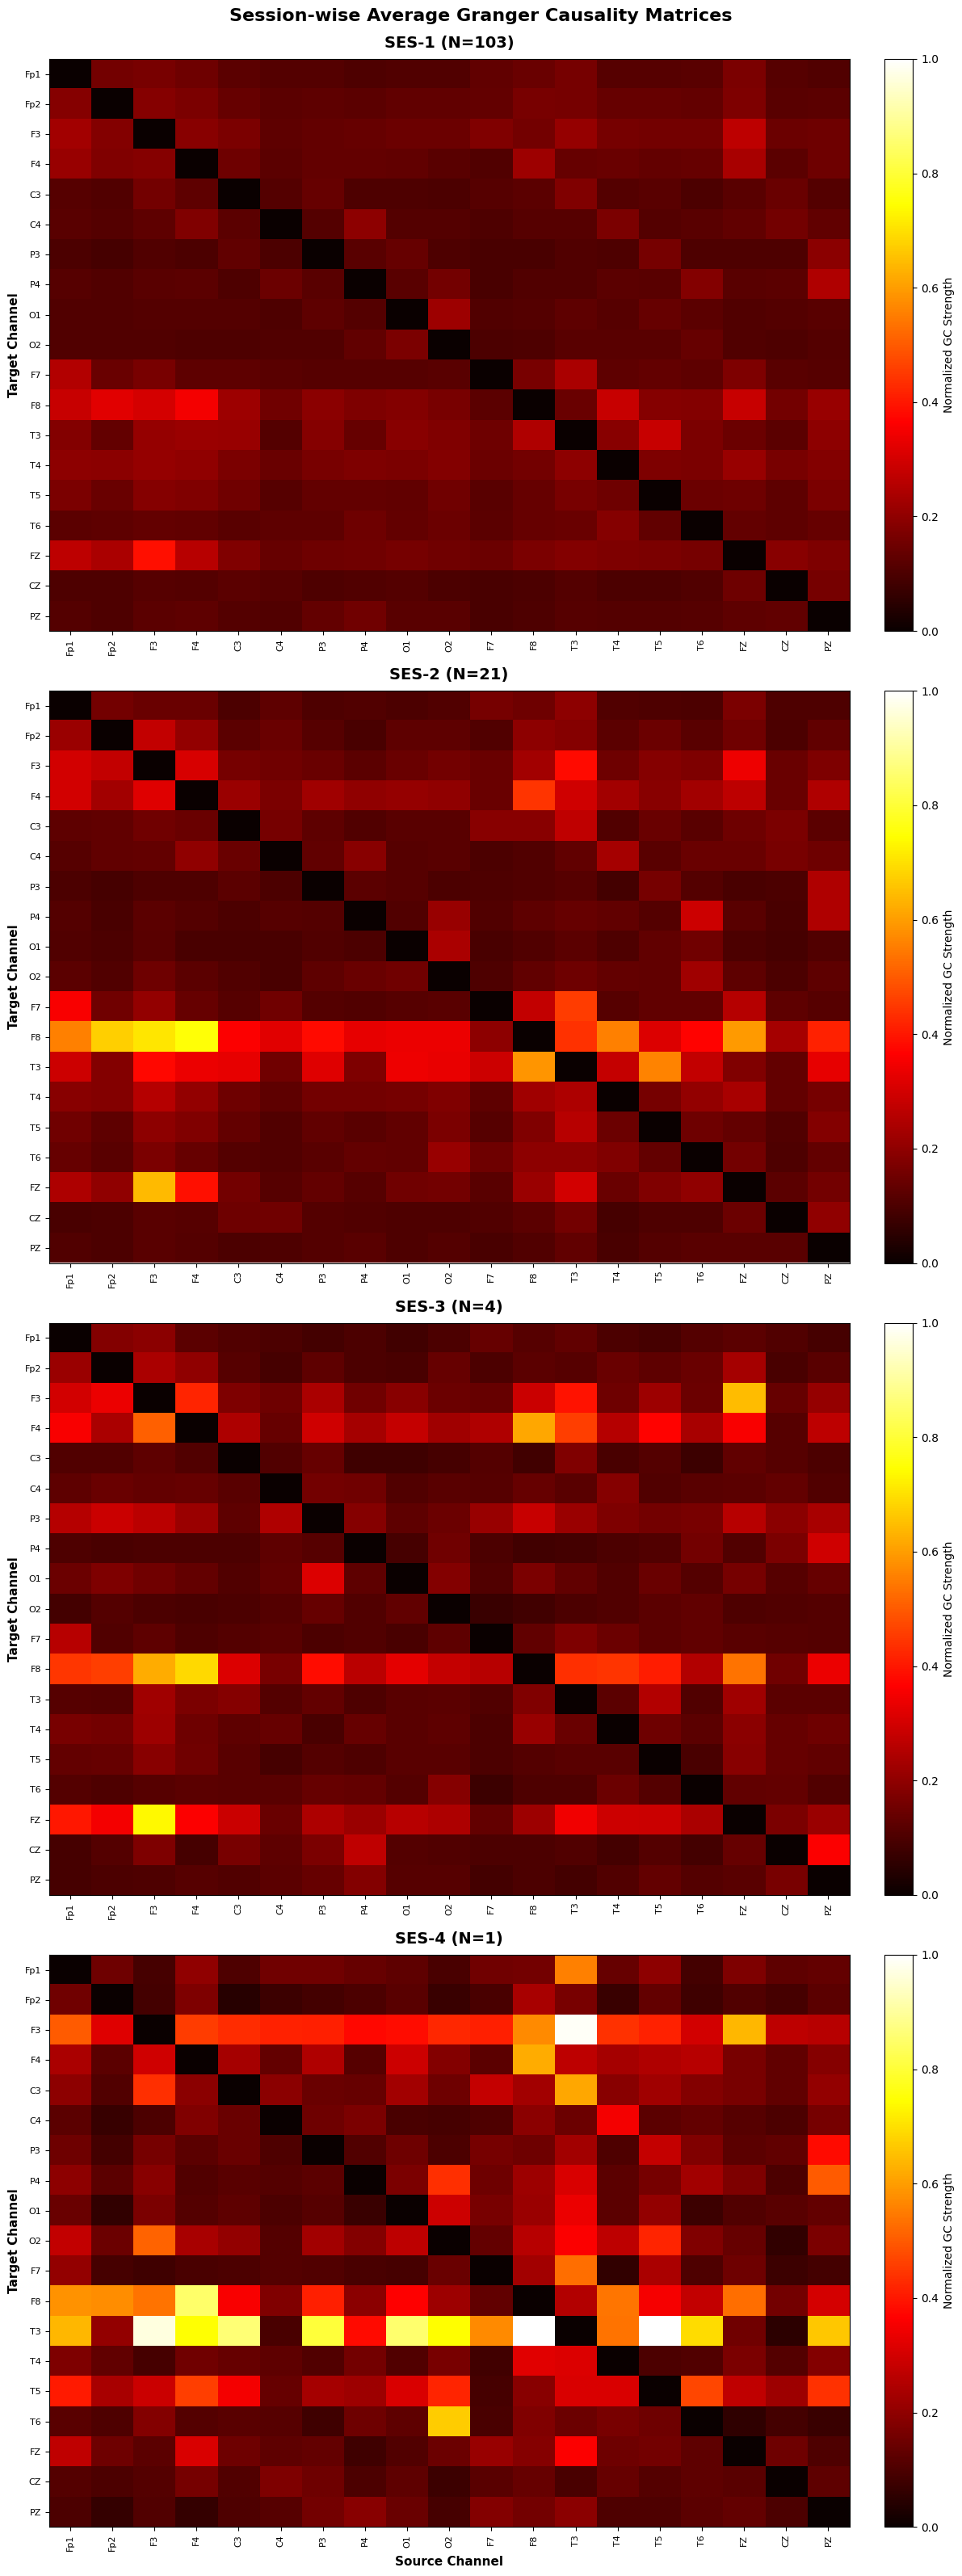

In [84]:
# Visualize session-wise comparison with heatmaps
if 'session_averages' in locals() and len(session_averages) > 0:
    # Create subplot for each session - VERTICAL ARRANGEMENT
    n_sessions = len(session_averages)
    fig, axes = plt.subplots(n_sessions, 1, figsize=(12, 8*n_sessions))
    
    # Handle single session case
    if n_sessions == 1:
        axes = [axes]
    
    # Get global min/max for consistent color scale
    all_values = np.concatenate([m.flatten() for m in session_averages.values()])
    vmin, vmax = all_values.min(), all_values.max()
    
    # Get channel names from a sample subject
    n_ch = list(session_averages.values())[0].shape[0]
    try:
        sample_subject = subjects[0] if 'subjects' in locals() else None
        if sample_subject:
            sample_files = list((dataset_path / sample_subject).rglob('*.edf'))
            if sample_files:
                sample_raw = mne.io.read_raw_edf(sample_files[0], preload=False, verbose=False)
                bad_ch = detect_bad_channels(sample_raw, 1e-12, 0.001)
                channel_names_list = [ch for ch in sample_raw.ch_names if ch not in bad_ch][:n_ch]
            else:
                channel_names_list = [f'Ch{i+1}' for i in range(n_ch)]
        else:
            channel_names_list = [f'Ch{i+1}' for i in range(n_ch)]
    except:
        channel_names_list = [f'Ch{i+1}' for i in range(n_ch)]
    
    # Ensure we have the right number of channel names
    if len(channel_names_list) != n_ch:
        channel_names_list = [f'Ch{i+1}' for i in range(n_ch)]
    
    print(f"Creating heatmaps for {n_sessions} sessions...")
    print(f"  Global range: [{vmin:.4f}, {vmax:.4f}]")
    print(f"  Using {len(channel_names_list)} channels: {', '.join(channel_names_list)}")
    
    for idx, (session_id, gc_avg) in enumerate(sorted(session_averages.items())):
        ax = axes[idx]
        
        # Normalize for visualization
        gc_normalized = (gc_avg - vmin) / (vmax - vmin) if vmax > vmin else gc_avg
        
        # Create heatmap
        im = ax.imshow(gc_normalized, cmap='hot', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
        
        # Title
        n_subjects = len(session_matrices[session_id])
        ax.set_title(f'{session_id.upper()} (N={n_subjects})', fontsize=14, fontweight='bold', pad=10)
        
        # Set channel names on axes
        ax.set_xticks(range(n_ch))
        ax.set_yticks(range(n_ch))
        ax.set_xticklabels(channel_names_list, rotation=90, ha='center', fontsize=8)
        ax.set_yticklabels(channel_names_list, fontsize=8)
        
        # Labels
        ax.set_ylabel('Target Channel', fontsize=11, fontweight='bold')
        if idx == n_sessions - 1:  # Only show x-label on bottom plot
            ax.set_xlabel('Source Channel', fontsize=11, fontweight='bold')
        
        # Add colorbar for each subplot
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Normalized GC Strength', fontsize=10)
    
    plt.suptitle('Session-wise Average Granger Causality Matrices', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    output_fig = results_dir / 'session_comparison_heatmaps.png'
    plt.savefig(output_fig, dpi=200, bbox_inches='tight')
    print(f"\n✓ Saved session comparison heatmaps to: {output_fig.name}")
    
    plt.show()
    
else:
    print("Error: Session averages not computed")

In [70]:
# Compute session-wise GC statistics and trends
if 'session_averages' in locals() and len(session_averages) > 0:
    print("=" * 70)
    print("SESSION-WISE GC TRENDS")
    print("=" * 70)
    
    # Extract session numbers for ordering
    session_order = sorted(session_averages.keys(), key=lambda x: int(re.search(r'\d+', x).group()))
    
    # Compute mean GC for each session (excluding diagonal)
    session_mean_gc = {}
    session_median_gc = {}
    session_max_gc = {}
    
    for session_id in session_order:
        gc_matrix = session_averages[session_id]
        
        # Exclude diagonal (self-connections)
        n_ch = gc_matrix.shape[0]
        mask = ~np.eye(n_ch, dtype=bool)
        gc_off_diagonal = gc_matrix[mask]
        
        session_mean_gc[session_id] = gc_off_diagonal.mean()
        session_median_gc[session_id] = np.median(gc_off_diagonal)
        session_max_gc[session_id] = gc_off_diagonal.max()
    
    # Display statistics
    print(f"\n Mean GC Strength (excluding self-connections):")
    for session_id in session_order:
        n_subjects = len(session_matrices[session_id])
        print(f"  {session_id}: {session_mean_gc[session_id]:.4f} (N={n_subjects})")
    
    print(f"\n Median GC Strength:")
    for session_id in session_order:
        print(f"  {session_id}: {session_median_gc[session_id]:.4f}")
    
    print(f"\n Maximum GC Strength:")
    for session_id in session_order:
        print(f"  {session_id}: {session_max_gc[session_id]:.4f}")
    
    # Compute percentage change across sessions
    if len(session_order) > 1:
        print(f"\n Change from {session_order[0]} to {session_order[-1]}:")
        first_mean = session_mean_gc[session_order[0]]
        last_mean = session_mean_gc[session_order[-1]]
        pct_change = ((last_mean - first_mean) / first_mean) * 100
        print(f"  Mean GC: {pct_change:+.2f}%")
        
        # Session-to-session changes
        print(f"\n Session-to-Session Changes (Mean GC):")
        for i in range(len(session_order) - 1):
            curr_session = session_order[i]
            next_session = session_order[i + 1]
            curr_mean = session_mean_gc[curr_session]
            next_mean = session_mean_gc[next_session]
            change = ((next_mean - curr_mean) / curr_mean) * 100
            print(f"  {curr_session} → {next_session}: {change:+.2f}%")
    
else:
    print("Error: Session averages not computed")

SESSION-WISE GC TRENDS

 Mean GC Strength (excluding self-connections):
  ses-1: 3.3389 (N=103)
  ses-2: 4.0546 (N=21)
  ses-3: 3.8999 (N=4)
  ses-4: 5.0862 (N=1)

 Median GC Strength:
  ses-1: 3.0368
  ses-2: 3.1964
  ses-3: 2.9835
  ses-4: 3.5456

 Maximum GC Strength:
  ses-1: 8.9897
  ses-2: 17.3101
  ses-3: 16.9610
  ses-4: 23.0258

 Change from ses-1 to ses-4:
  Mean GC: +52.33%

 Session-to-Session Changes (Mean GC):
  ses-1 → ses-2: +21.44%
  ses-2 → ses-3: -3.82%
  ses-3 → ses-4: +30.42%


In [72]:
# Analyze individual subjects across sessions (longitudinal analysis)
if 'multi_session_subjects' in locals() and len(multi_session_subjects) > 0:
    print("=" * 70)
    print("LONGITUDINAL ANALYSIS (Subjects with Multiple Sessions)")
    print("=" * 70)
    
    # Find subjects with all 4 sessions (or most sessions)
    session_count_dist = {}
    for subj, sessions in multi_session_subjects.items():
        n_sess = len(sessions)
        if n_sess not in session_count_dist:
            session_count_dist[n_sess] = []
        session_count_dist[n_sess].append(subj)
    
    print(f"\n Distribution of session counts:")
    for n_sess in sorted(session_count_dist.keys(), reverse=True):
        print(f"  {n_sess} sessions: {len(session_count_dist[n_sess])} subjects")
    
    # Analyze subjects with maximum number of sessions
    max_sessions = max(session_count_dist.keys())
    subjects_with_max = session_count_dist[max_sessions]
    
    print(f"\n Analyzing {len(subjects_with_max)} subjects with {max_sessions} sessions:")
    
    # Compute individual subject trajectories
    subject_trajectories = {}
    
    for subject_id in subjects_with_max[:10]:  # Show first 10
        sessions = subject_session_data[subject_id]
        session_ids = sorted(sessions.keys(), key=lambda x: int(re.search(r'\d+', x).group()))
        
        # Compute mean GC for each session
        trajectory = []
        for sess_id in session_ids:
            gc_matrix = sessions[sess_id]
            n_ch = gc_matrix.shape[0]
            mask = ~np.eye(n_ch, dtype=bool)
            mean_gc = gc_matrix[mask].mean()
            trajectory.append(mean_gc)
        
        subject_trajectories[subject_id] = {
            'sessions': session_ids,
            'mean_gc': trajectory
        }
        
        # Display trajectory
        print(f"\n  {subject_id}:")
        for sess_id, gc_val in zip(session_ids, trajectory):
            print(f"    {sess_id}: {gc_val:.4f}")
        
        # Compute trend
        if len(trajectory) > 1:
            change = ((trajectory[-1] - trajectory[0]) / trajectory[0]) * 100
            print(f"    Overall change: {change:+.2f}%")
    
    if len(subjects_with_max) > 10:
        print(f"\n  ... and {len(subjects_with_max) - 10} more subjects")
    
else:
    print("\nNo subjects with multiple sessions found")

LONGITUDINAL ANALYSIS (Subjects with Multiple Sessions)

 Distribution of session counts:
  4 sessions: 1 subjects
  3 sessions: 3 subjects
  2 sessions: 17 subjects

 Analyzing 1 subjects with 4 sessions:

  sub-NORB00069:
    ses-1: 3.3459
    ses-2: 4.1134
    ses-3: 4.0461
    ses-4: 5.0862
    Overall change: +52.01%


## Step 9: Sex-Based Analysis

Compare Granger Causality patterns between male and female infants.

In [97]:
# Load sex data and organize GC matrices by sex
participants_df = pd.read_csv(dataset_path / 'participants.tsv', sep='\t')
sex_map = dict(zip(participants_df['participant_id'], participants_df['sex']))

male_matrices, female_matrices = [], []

for gc_file in gc_files:
    match = re.match(r'(sub-NORB\d+)_(ses-\d+)_gc_matrix', gc_file.stem)
    if match:
        subject_id = match.group(1)
        sex = sex_map.get(subject_id)
        gc_matrix = np.load(gc_file)
        
        if gc_matrix.shape == most_common_shape:
            if sex == 'M':
                male_matrices.append(gc_matrix)
            elif sex == 'F':
                female_matrices.append(gc_matrix)

male_avg = np.mean(male_matrices, axis=0)
female_avg = np.mean(female_matrices, axis=0)

print(f"✓ Sex-based groups:")
print(f"  Male: {len(male_matrices)} recordings")
print(f"  Female: {len(female_matrices)} recordings")

✓ Sex-based groups:
  Male: 78 recordings
  Female: 50 recordings


In [101]:
# Statistical comparison between sexes
from scipy import stats

n_ch = male_avg.shape[0]
mask = ~np.eye(n_ch, dtype=bool)

male_mean = male_avg[mask].mean()
female_mean = female_avg[mask].mean()

# T-test between male and female GC values
male_vals = np.array([m[mask].flatten() for m in male_matrices]).flatten()
female_vals = np.array([m[mask].flatten() for m in female_matrices]).flatten()

print(f"\n Sex Comparison Statistics:")
print(f"  Male mean GC: {male_mean:.4f}")
print(f"  Female mean GC: {female_mean:.4f}")
print(f"  Difference: {((female_mean - male_mean) / male_mean * 100):+.2f}%")


 Sex Comparison Statistics:
  Male mean GC: 3.5541
  Female mean GC: 3.3836
  Difference: -4.80%



Found 2 bad channel(s): ['Pg1', 'Pg2']
Using 19 channels: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, FZ, CZ, PZ


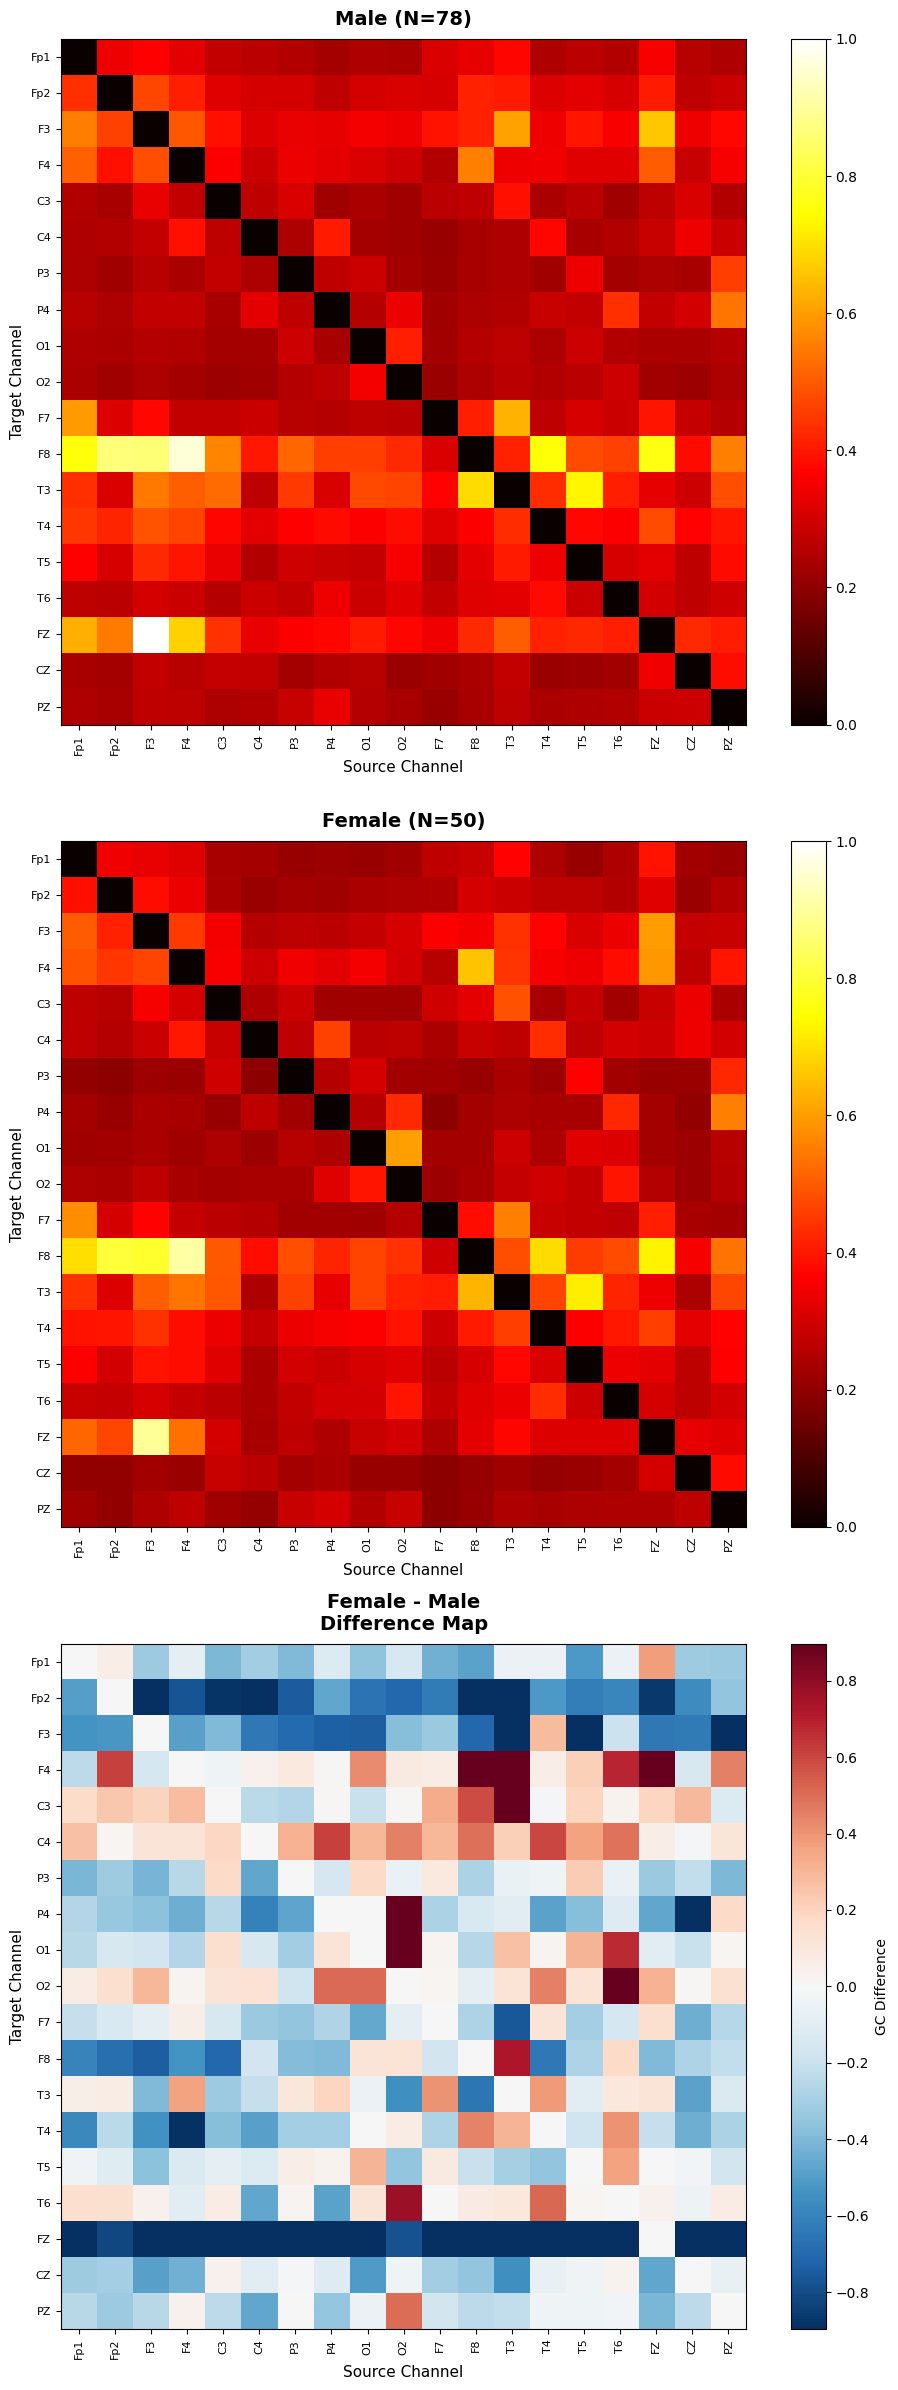

✓ Saved sex comparison plots


In [104]:
# Visualize sex-based comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 24))

# Get channel names
n_ch = male_avg.shape[0]
try:
    sample_subject = subjects[0] if 'subjects' in locals() else None
    if sample_subject:
        sample_files = list((dataset_path / sample_subject).rglob('*.edf'))
        if sample_files:
            sample_raw = mne.io.read_raw_edf(sample_files[0], preload=False, verbose=False)
            bad_ch = detect_bad_channels(sample_raw, 1e-12, 0.001)
            channel_names_sex = [ch for ch in sample_raw.ch_names if ch not in bad_ch][:n_ch]
        else:
            channel_names_sex = [f'Ch{i+1}' for i in range(n_ch)]
    else:
        channel_names_sex = [f'Ch{i+1}' for i in range(n_ch)]
except:
    channel_names_sex = [f'Ch{i+1}' for i in range(n_ch)]

if len(channel_names_sex) != n_ch:
    channel_names_sex = [f'Ch{i+1}' for i in range(n_ch)]

print(f"Using {len(channel_names_sex)} channels: {', '.join(channel_names_sex)}")

# Shared colorbar range
vmin = min(male_avg.min(), female_avg.min())
vmax = max(male_avg.max(), female_avg.max())

# Male heatmap
ax = axes[0]
gc_norm = (male_avg - vmin) / (vmax - vmin)
im = ax.imshow(gc_norm, cmap='hot', vmin=0, vmax=1)
ax.set_title(f'Male (N={len(male_matrices)})', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Source Channel', fontsize=11)
ax.set_ylabel('Target Channel', fontsize=11)
ax.set_xticks(range(n_ch))
ax.set_yticks(range(n_ch))
ax.set_xticklabels(channel_names_sex, rotation=90, ha='center', fontsize=8)
ax.set_yticklabels(channel_names_sex, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Female heatmap
ax = axes[1]
gc_norm = (female_avg - vmin) / (vmax - vmin)
im = ax.imshow(gc_norm, cmap='hot', vmin=0, vmax=1)
ax.set_title(f'Female (N={len(female_matrices)})', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Source Channel', fontsize=11)
ax.set_ylabel('Target Channel', fontsize=11)
ax.set_xticks(range(n_ch))
ax.set_yticks(range(n_ch))
ax.set_xticklabels(channel_names_sex, rotation=90, ha='center', fontsize=8)
ax.set_yticklabels(channel_names_sex, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Difference map
ax = axes[2]
diff = female_avg - male_avg
im = ax.imshow(diff, cmap='RdBu_r', vmin=-diff.std()*2, vmax=diff.std()*2)
ax.set_title('Female - Male\nDifference Map', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Source Channel', fontsize=11)
ax.set_ylabel('Target Channel', fontsize=11)
ax.set_xticks(range(n_ch))
ax.set_yticks(range(n_ch))
ax.set_xticklabels(channel_names_sex, rotation=90, ha='center', fontsize=8)
ax.set_yticklabels(channel_names_sex, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='GC Difference')

plt.tight_layout()
plt.savefig(results_dir / 'sex_comparison.png', dpi=200)
plt.show()
print("✓ Saved sex comparison plots")